В качестве сайта для получения отзывов пользователей будем использовать [Restoran](https://www.restoran.ru/msk/opinions/)

Парсинг производится с помощью пакета BS4

In [1]:
import time
import re

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Задание №1. Класс для парсинга сайта.

Для этого вручную был исследован сайт, классы различных тегов.

In [3]:
class RestoranParser:
    def __init__(self):
        self.base_url = 'https://www.restoran.ru/msk/opinions/'
        self.headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
        }

        self.reviews = []

    def get_page_content(self, page_num: int):
        url = f"{self.base_url}?PAGEN_1={page_num}"
        try:
            response = requests.get(url, headers=self.headers)
            response.raise_for_status()
            return response.text
        except requests.exceptions.RequestException as e:
            print(f"Error fetching page {page_num}: {e}")
            return None


    def scrape_reviews(self, max_pages=10, delay=1) -> pd.DataFrame:
        print(f"Начинаем сбор отзывов с {max_pages} страниц...")
        
        for page_num in range(1, max_pages + 1):
            print(f"Обрабатываем страницу {page_num}...")
            
            content = self.get_page_content(page_num)
            if not content:
                continue
                
            soup = BeautifulSoup(content, 'html.parser')
            
            review_list = soup.find('div', class_='review-list-wrap')
            review_blocks = review_list.find_all('div', attrs={'class': 'review-wrap'})
            
            if not review_blocks:
                print(f"На странице {page_num} отзывы не найдены")
                continue
            
            successful_parses = 0
            for i, block in enumerate(review_blocks):
                if block is None:
                    print(f"Блок {i+1} равен None, пропускаем")
                    continue
                
                review_data = self.parse_review_block(block)
                if review_data:
                    self.reviews.append(review_data)
                    successful_parses += 1
        
            print(f"Собрано отзывов с страницы {page_num}: {successful_parses} из {len(review_blocks)}")
            
            # Задержка между запросами
            time.sleep(delay)
        
        print(f"Общее количество собранных отзывов: {len(self.reviews)}")
        return pd.DataFrame(self.reviews)

    def parse_review_block(self, review_block):
        review_data = {}
        
        try:
            # Название ресторана
            restaurant_name = review_block.find('div', class_='place-name-wrap')
            restaurant_link = restaurant_name.find('a')
            review_data['restaurant_name'] = restaurant_link.get_text(strip=True) if restaurant_name else "Не указано"
            
            # Ссылка на ресторан
            review_data['restaurant_url'] = restaurant_link.get('href') if restaurant_link else "Не указано"
            
            # Рейтинг
            rating_element = review_block.find('div', class_='place-rating').find('span')
            review_data['rating'] = rating_element.get_text(strip=True) if rating_element else "Не указано"

            # Текст отзыва
            review_text = review_block.find('div', class_='review-text-wrap').find('span', class_='review-text-full')
            review_data['review_text'] = review_text.get_text(strip=True) if review_text else "Текст отсутствует"
            
            # Автор отзыва
            info_about_review = review_block.find('div', class_='ava-rating-wrap')
            author_element = info_about_review.find('div', class_='avatar-date-wrap').find('div', class_='user-name')
            review_data['author'] = author_element.get_text(strip=True) if author_element else "Аноним"
            
            # Дата отзыва
            date_element = info_about_review.find('div', class_='avatar-date-wrap').find('div', class_='review-date')
            if date_element:
                date_text = date_element.get_text(strip=True)
                review_data['review_date'] = self.parse_date(date_text)
            else:
                review_data['review_date'] = "Дата не указана"

            # Оценка в данном отзыве
            review_mark_block = info_about_review.find('div', class_='review-rating-wrap')
            review_mark = review_mark_block.find('div', class_='review-rating has-grade-values')
            review_data['mark'] = review_mark.find('span').get_text(strip=True) if review_mark else None

            return review_data

        except Exception as e:
            print(f"Ошибка при парсинге отзыва: {e}")
            return None


    def parse_date(self, date_string):
        try:
            months_ru = {
                'января': '01', 'февраля': '02', 'марта': '03', 'апреля': '04',
                'мая': '05', 'июня': '06', 'июля': '07', 'августа': '08',
                'сентября': '09', 'октября': '10', 'ноября': '11', 'декабря': '12'
            }
            
            for month_ru, month_num in months_ru.items():
                if month_ru in date_string:
                    date_parts = date_string.replace(month_ru, month_num).split()
                    if len(date_parts) >= 3:
                        day = date_parts[0].zfill(2)
                        month = month_num
                        year = date_parts[2]
                        return f"{year}-{month}-{day}"
            
            return date_string
        except Exception as e:
            print(f"Произошла ошибка при преобразовании даты: {date_string} - {e}")
            return date_string

    def save_to_csv(self, filename="restaurant_reviews.csv"):
        if self.reviews:
            df = pd.DataFrame(self.reviews)
            df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')
            df.to_csv(filename, index=False, encoding='utf-8-sig')
            print(f"Данные сохранены в файл: {filename}")
            return df
        else:
            print("Нет данных для сохранения")
            return None

Мы берём для анализа первые `max_pages` страниц отзывов и с каждого отзыва получаем информацию:

- `restaurant_name` - Название ресторана
- `restaurant_url` - URL-ссылка на сведения о ресторане
- `rating` - Средняя оценка ресторана на сайте с отзывами
- `review_text` - Текст отзыва
- `author` - Автор отзыва
- `review_date` - Дата отзыва
- `mark` - Оценка поставленная ресторану в отзыве

In [4]:
rest_parser = RestoranParser()
df = rest_parser.scrape_reviews()

display(df)

Начинаем сбор отзывов с 10 страниц...
Обрабатываем страницу 1...
Собрано отзывов с страницы 1: 20 из 20
Обрабатываем страницу 2...
Собрано отзывов с страницы 2: 20 из 20
Обрабатываем страницу 3...
Собрано отзывов с страницы 3: 20 из 20
Обрабатываем страницу 4...
Ошибка при парсинге отзыва: 'NoneType' object has no attribute 'find'
Собрано отзывов с страницы 4: 19 из 20
Обрабатываем страницу 5...
Собрано отзывов с страницы 5: 20 из 20
Обрабатываем страницу 6...
Собрано отзывов с страницы 6: 20 из 20
Обрабатываем страницу 7...
Собрано отзывов с страницы 7: 20 из 20
Обрабатываем страницу 8...
Собрано отзывов с страницы 8: 20 из 20
Обрабатываем страницу 9...
Собрано отзывов с страницы 9: 20 из 20
Обрабатываем страницу 10...
Собрано отзывов с страницы 10: 20 из 20
Общее количество собранных отзывов: 199


,restaurant_name,restaurant_url,rating,review_text,author,review_date,mark
0,Ресторан Mendeleev. Bar & Music,/msk/detailed/restaurants/mendeleev-bar-music/,4.7,Текст отсутствует,Настя,2025-10-15,4.0
1,Ресторан Artiland / Артиленд,/msk/detailed/restaurants/arti-land/,4.8,"Это место просто великолепное, и уверена, со м...",Светлана,2025-10-15,5.0
2,Ресторан Лодка,/msk/detailed/restaurants/lodka/,4.9,Любителям азиатской кухни рекомендую к посещен...,Евгения,2025-10-15,5.0
3,Ресторан Бакинский бульвар (Кутузовский пр.),/msk/detailed/restaurants/bakinskiy-bulvar-na-...,5,Текст отсутствует,Сервин,2025-10-14,5.0
4,Банкетный зал Веста,/msk/detailed/banket/vesta/,4.9,просто невероятно! Новый год в этом ресторане ...,Anna,2025-10-13,5.0
...,...,...,...,...,...,...,...
194,Ресторан Tanuki / Тануки,/msk/detailed/restaurants/tanuki/,3.5,"Попробовали разные роллы, все вкусные. Приятно...",Алина,2025-06-06,5.0
195,Ресторан Лодка,/msk/detailed/restaurants/lodka/,4.9,"Очень нравится здешняя атмосфера и кухня, были...",Janna81,2025-06-06,5.0
196,Ресторан Бочка,/msk/detailed/restaurants/botchka/,4.9,"Одни из лучших стейков в городе, на мой взгляд...",Степан,2025-06-05,5.0
197,Ресторан Artiland / Артиленд,/msk/detailed/restaurants/arti-land/,4.8,Ресторан ARTILAND это прекрасное место для отд...,Захар Виноградов,2025-06-04,5.0


# Задание №2-3. Класс для обработки данных и визуализации.

In [5]:
from datetime import datetime, timedelta

class RestaurantDataProcessor:
    def __init__(self, df=None, csv_file=None):
        if df is not None:
            self.df = df.copy()
        elif csv_file is not None:
            self.df = pd.read_csv(csv_file, encoding='utf-8-sig')
        else:
            raise Exception("Нет источника данных")
        
        self.original_shape = self.df.shape
        print(f"Загружено данных: {self.original_shape[0]} строк, {self.original_shape[1]} столбцов")
    
    def clean_data(self):
        print("=== НАЧАЛО ОЧИСТКИ ДАННЫХ ===\n")
        
        self._clean_restaurant_names()
        self._clean_urls()
        self._clean_ratings()
        self._clean_review_text()
        self._clean_authors()
        self._clean_dates()
        self._clean_marks()
        
        self._remove_duplicates()
        
        print(f"\n=== РЕЗУЛЬТАТ ОЧИСТКИ ===")
        print(f"Было строк: {self.original_shape[0]}")
        print(f"Стало строк: {self.df.shape[0]}")
        print(f"Удалено строк: {self.original_shape[0] - self.df.shape[0]}")
        print(f"Процент оставшихся данных: {(self.df.shape[0] / self.original_shape[0]) * 100:.1f}%")
        
        return self.df
    
    def _clean_restaurant_names(self):
        self.df = self.df.dropna(subset=['restaurant_name'])
                
        print(f"Уникальных ресторанов: {self.df['restaurant_name'].nunique()}")
    
    def _clean_urls(self):
        print("Очистка URL адресов...")
        self.df['restaurant_url'] = self.df['restaurant_url'].fillna('URL не указан')
    
    def _clean_ratings(self):
        print("Очистка рейтингов...")
        
        self.df['rating'] = pd.to_numeric(self.df['rating'], errors='coerce')
        
        outliers_before = self.df['rating'].isna().sum()
        self.df.loc[(self.df['rating'] < 1) | (self.df['rating'] > 5), 'rating'] = np.nan
        outliers_after = self.df['rating'].isna().sum()
        
        print(f"Выбросов в рейтингах обнаружено: {outliers_after - outliers_before}")
    
    def _clean_review_text(self):
        print("Очистка текстов отзывов...")
        
        self.df['review_text'] = self.df['review_text'].fillna('Текст отзыва отсутствует')
        self.df['review_text'] = self.df['review_text'].replace('', 'Текст отзыва отсутствует')

        self.df['review_text'] = self.df['review_text'].str.strip()
        self.df['review_length'] = self.df['review_text'].str.len()
        
        mask = (self.df['review_length'] < 10) & (self.df['review_text'] != 'Текст отзыва отсутствует')
        removed_short = mask.sum()
        self.df = self.df[~mask]
        
        print(f"Удалено слишком коротких отзывов: {removed_short}")
    
    def _clean_authors(self):
        print("Очистка авторов...")
        
        self.df['author'] = self.df['author'].fillna('Аноним')
        self.df['author'] = self.df['author'].replace('', 'Аноним')
        self.df['author'] = self.df['author'].str.strip()
        
        print(f"Уникальных авторов: {self.df['author'].nunique()}")
    
    def _clean_dates(self):
        print("Очистка дат...")
        
        # Конвертация в datetime
        self.df['review_date'] = pd.to_datetime(self.df['review_date'], errors='coerce')
        
        current_date = datetime.now()
        old_date = current_date - timedelta(days=365*10)
        
        future_dates = (self.df['review_date'] > current_date).sum()
        old_dates = (self.df['review_date'] < old_date).sum()
        
        self.df.loc[self.df['review_date'] > current_date, 'review_date'] = np.nan
        self.df.loc[self.df['review_date'] < old_date, 'review_date'] = np.nan
        
        self.df.dropna(subset=['review_date'], inplace=True)
        print(f"Удалено дат из будущего: {future_dates}")
        print(f"Удалено слишком старых дат: {old_dates}")

    
    def _clean_marks(self):
        print("Очистка оценок отзывов...")
        self.df['mark'] = pd.to_numeric(self.df['mark'], errors='coerce').astype(int)
        
        outliers_before = self.df['mark'].isna().sum()
        self.df.loc[(self.df['mark'] < 1) | (self.df['mark'] > 5), 'mark'] = np.nan
        outliers_after = self.df['mark'].isna().sum()
        
        self.df.dropna(subset=['mark'], inplace=True)
        print(f"Выбросов в оценках удалено: {outliers_after - outliers_before}")
    
    def _remove_duplicates(self):
        print("Удаление дубликатов...")
        
        before = self.df.shape[0]
        self.df = self.df.drop_duplicates()
        
        # Удаление дубликатов по ключевым полям
        self.df = self.df.drop_duplicates(
            subset=['restaurant_name', 'author', 'review_text'], 
            keep='first'
        )
        
        after = self.df.shape[0]
        print(f"Удалено дубликатов: {before - after}")

    def descriptive_statistics(self):
        print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
        print("="*50)
        
        print(f"\nОБЩАЯ ИНФОРМАЦИЯ:")
        print(f"Количество отзывов: {len(self.df)}")
        print(f"Период данных: {self.df['review_date'].min()} - {self.df['review_date'].max()}")
        print(f"Количество уникальных ресторанов: {self.df['restaurant_name'].nunique()}")
        print(f"Количество уникальных авторов: {self.df['author'].nunique()}")
        
        # Статистика по числовым переменным
        print(f"\nЧИСЛОВЫЕ ПЕРЕМЕННЫЕ:")
        numeric_cols = ['rating', 'mark', 'review_length']
        for col in numeric_cols:
            if col in self.df.columns and not self.df[col].empty:
                print(f"\n{col.upper()}:")
                print(f"  Среднее: {self.df[col].mean():.2f}")
                print(f"  Медиана: {self.df[col].median():.2f}")
                print(f"  Минимум: {self.df[col].min():.2f}")
                print(f"  Максимум: {self.df[col].max():.2f}")
        
        print(f"\nТОП-10 РЕСТОРАНОВ ПО КОЛИЧЕСТВУ ОТЗЫВОВ:")
        top_restaurants = self.df['restaurant_name'].value_counts().head(10)
        for restaurant, count in top_restaurants.items():
            print(f"  {restaurant}: {count} отзывов")
        
        # Топ авторов
        print(f"\nТОП-10 АВТОРОВ ПО КОЛИЧЕСТВУ ОТЗЫВОВ:")
        top_authors = self.df['author'].value_counts().head(10)
        for author, count in top_authors.items():
            print(f"  {author}: {count} отзывов")
        
        # Распределение оценок
        if 'mark' in self.df.columns:
            print(f"\nРАСПРЕДЕЛЕНИЕ ОЦЕНОК:")
            mark_dist = self.df['mark'].value_counts().sort_index()
            for mark, count in mark_dist.items():
                if not pd.isna(mark):
                    print(f"  Оценка {int(mark)}: {count} отзывов ({count/len(self.df)*100:.1f}%)")
        
        # Активность по месяцам
        if 'review_date' in self.df.columns:
            print(f"\nАКТИВНОСТЬ ПО МЕСЯЦАМ (последние 12 месяцев):")
            self.df['month_year'] = self.df['review_date'].dt.to_period('M')
            monthly_activity = self.df['month_year'].value_counts().sort_index().tail(12)
            for period, count in monthly_activity.items():
                if not pd.isna(period):
                    print(f"  {period}: {count} отзывов")
        
        return self._create_summary_dict()
    
    def _create_summary_dict(self):
        summary = {
            'total_reviews': len(self.df),
            'unique_restaurants': self.df['restaurant_name'].nunique(),
            'unique_authors': self.df['author'].nunique(),
            'avg_rating': self.df['rating'].mean() if 'rating' in self.df.columns else None,
            'avg_mark': self.df['mark'].mean() if 'mark' in self.df.columns else None,
            'avg_review_length': self.df['review_length'].mean() if 'review_length' in self.df.columns else None,
            'date_range': f"{self.df['review_date'].min()} - {self.df['review_date'].max()}" if 'review_date' in self.df.columns else None
        }
        return summary
    
    def create_visualizations(self):
        """Создание визуализаций"""
        plt.style.use('default')
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        fig.suptitle('Анализ данных отзывов о ресторанах', fontsize=16, fontweight='bold')
        
        # 1. Распределение рейтингов
        if 'rating' in self.df.columns and not self.df['rating'].empty:
            axes[0, 0].hist(self.df['rating'].dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
            axes[0, 0].set_title('Распределение рейтингов ресторанов')
            axes[0, 0].set_xlabel('Рейтинг')
            axes[0, 0].set_ylabel('Количество')
        
        # 2. Распределение оценок отзывов
        if 'mark' in self.df.columns and not self.df['mark'].empty:
            mark_counts = self.df['mark'].value_counts().sort_index()
            axes[0, 1].bar(mark_counts.index, mark_counts.values, alpha=0.7, color='lightcoral')
            axes[0, 1].set_title('Распределение оценок в отзывах')
            axes[0, 1].set_xlabel('Оценка')
            axes[0, 1].set_ylabel('Количество отзывов')
        
        # 3. Топ-10 ресторанов
        top_rest = self.df['restaurant_name'].value_counts().head(10)
        axes[1, 0].barh(range(len(top_rest)), top_rest.values, color='orange', alpha=0.7)
        axes[1, 0].set_yticks(range(len(top_rest)))
        axes[1, 0].set_yticklabels(top_rest.index, fontsize=8)
        axes[1, 0].set_title('Топ-10 ресторанов по количеству отзывов')
        axes[1, 0].set_xlabel('Количество отзывов')
        
        # 4. Активность по месяцам
        if 'review_date' in self.df.columns:
            monthly = self.df.set_index('review_date').resample('ME').size()
            axes[1, 1].plot(monthly.index, monthly.values, marker='o', color='purple', alpha=0.7)
            axes[1, 1].set_title('Активность отзывов по месяцам')
            axes[1, 1].set_xlabel('Месяц')
            axes[1, 1].set_ylabel('Количество отзывов')
            plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)
        
        axes[0, 0].set_title('Рисунок 1. Распределение рейтингов ресторанов')
        axes[0, 1].set_title('Рисунок 2. Распределение оценок в отзывах')
        axes[1, 0].set_title('Рисунок 3. Топ-10 ресторанов по количеству отзывов')
        axes[1, 1].set_title('Рисунок 4. Активность отзывов по месяцам')
        plt.tight_layout()
        plt.show()
    
    def get_data_quality_report(self):
        """Отчет о качестве данных"""
        print("\n" + "="*50)
        print("ОТЧЕТ О КАЧЕСТВЕ ДАННЫХ")
        print("="*50)
        
        total_cells = self.df.shape[0] * self.df.shape[1]
        missing_cells = self.df.isnull().sum().sum()
        
        print(f"Общее количество ячеек: {total_cells}")
        print(f"Пропущенные значения: {missing_cells} ({missing_cells/total_cells*100:.1f}%)")
        print(f"Заполненность данных: {(total_cells-missing_cells)/total_cells*100:.1f}%")
        
        print("\nПропуски по столбцам:")
        for col in self.df.columns:
            missing = self.df[col].isnull().sum()
            missing_pct = (missing / len(self.df)) * 100
            print(f"  {col}: {missing} ({missing_pct:.1f}%)")
        
        # Проверка на дубликаты
        duplicates = self.df.duplicated().sum()
        print(f"\nПолные дубликаты: {duplicates}")
        
        return {
            'total_cells': total_cells,
            'missing_cells': missing_cells,
            'completeness': (total_cells-missing_cells)/total_cells*100,
            'duplicates': duplicates
        }

Загружено данных: 199 строк, 7 столбцов
=== НАЧАЛО ОЧИСТКИ ДАННЫХ ===

Уникальных ресторанов: 56
Очистка URL адресов...
Очистка рейтингов...
Выбросов в рейтингах обнаружено: 0
Очистка текстов отзывов...
Удалено слишком коротких отзывов: 0
Очистка авторов...
Уникальных авторов: 143
Очистка дат...
Удалено дат из будущего: 0
Удалено слишком старых дат: 0
Очистка оценок отзывов...
Выбросов в оценках удалено: 0
Удаление дубликатов...
Удалено дубликатов: 24

=== РЕЗУЛЬТАТ ОЧИСТКИ ===
Было строк: 199
Стало строк: 175
Удалено строк: 24
Процент оставшихся данных: 87.9%
ОПИСАТЕЛЬНАЯ СТАТИСТИКА

ОБЩАЯ ИНФОРМАЦИЯ:
Количество отзывов: 175
Период данных: 2025-06-03 00:00:00 - 2025-10-15 00:00:00
Количество уникальных ресторанов: 56
Количество уникальных авторов: 143

ЧИСЛОВЫЕ ПЕРЕМЕННЫЕ:

RATING:
  Среднее: 4.18
  Медиана: 4.40
  Минимум: 1.00
  Максимум: 5.00

MARK:
  Среднее: 4.21
  Медиана: 5.00
  Минимум: 1.00
  Максимум: 5.00

REVIEW_LENGTH:
  Среднее: 331.07
  Медиана: 246.00
  Минимум: 17.00


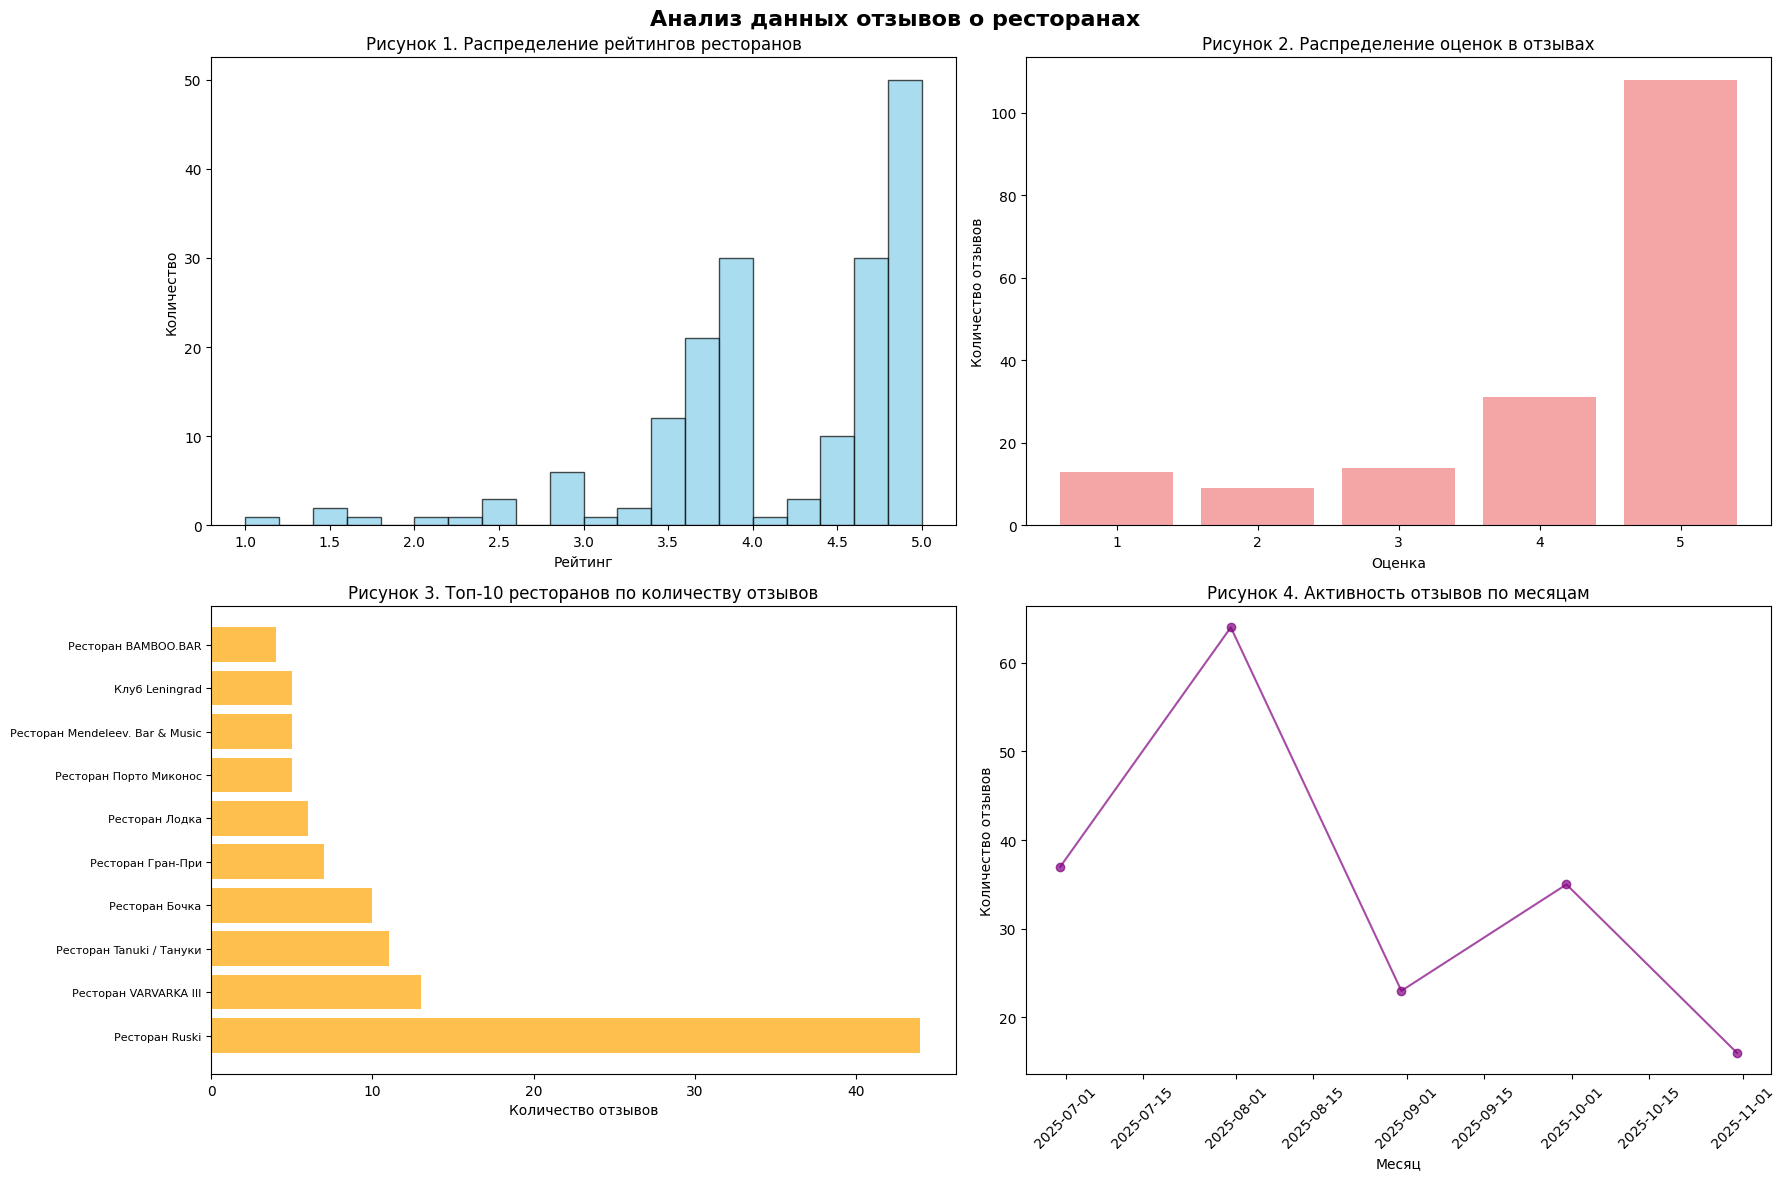

In [6]:
processor = RestaurantDataProcessor(df=df)

cleaned_data = processor.clean_data()

stats = processor.descriptive_statistics()

quality_report = processor.get_data_quality_report()

processor.create_visualizations()

## Задание №3. Практические выводы

- Рисунок №1. Можем заметить преобладание средних оценов ресторанов в диапазоне от 4 до 5. То есть в целом, можно сказать, что вопиюще плохих заведений мало.
Они либо быстро закрываются из-за конкуренции, либо пользуясь сарафанным радио теряют своих посетителей настолько быстро, что к ним не успевают прийти и оставить плохой отзыв.

- Рисунок №2. Видим большой перекос оценки, оставленной пользователями (в рамках одного отзыва) в сторону наивысшего балла. Можем говорить о том, что это связано с высоким качеством обслуживания в сфере общепита работы с клиентами (довольно популярный факт). Так же, можем аккуратно предположить, что данные оценки вызваны различными пиар акциями, в рамках которых за хорошую оценку, ресторан может сделать скидку или блюдо в подарок и т.д.

- Рисунок №3. Свительствует о повышенном интересе к заведению `Ruski`. У ресторана либо потрясающая посещаемость, либо идёт накрутка отзывов. Изучая подробнее данное заведение, можно прийти к выводу о том, что первое утверждение ближе к истине. Поскольку ресторан является довольно популярным, имеет огромную пиар компанию, различные рекомендации в разных соц сетях. В конце концов, находится в одном из самых популярных мест Москвы.

# Задание №4. Проведение аналитики классов.

In [7]:
from sklearn.utils import resample

def process_unbalanced_classes(df):

    print("\n1. АНАЛИЗ ИСХОДНОГО РАСПРЕДЕЛЕНИЯ КЛАССОВ")
    print("-"*50)
    
    df_clean = df.dropna(subset=['mark']).copy()

    df_clean['mark'] = pd.to_numeric(df_clean['mark'])
    class_counts = df_clean['mark'].value_counts().sort_index()
    
    print("Распределение классов (оценок):")
    for mark, count in class_counts.items():
        percentage = (count / len(df_clean)) * 100
        print(f"Класс {mark}: {count} отзывов ({percentage:.1f}%)")
    
    print(f"\nОбщее количество отзывов: {len(df_clean)}")
    
    # 2. Визуализация распределения классов
    print("\n2. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ")
    print("-"*40)
    
    plt.figure(figsize=(12, 8))
    
    plt.pie(class_counts.values, labels=[f'Класс {int(x)}' for x in class_counts.index], 
            autopct='%1.1f%%', startangle=90)
    plt.title('Доли классов в несбалансированной выборке', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print("\n3. СТРАТЕГИЯ БАЛАНСИРОВКИ")
    print("-"*35)
    
    target_count = class_counts.get(1.0, class_counts.min())
    print(f"Целевое количество для каждого класса: {target_count}")
    
    print("\nСтратегия для каждого класса:")
    for mark, count in class_counts.items():
        if count > target_count:
            print(f"Класс {int(mark)}: МАЖОРИТАРНЫЙ - применяем Random Undersampling ({count} → {target_count})")
        elif count < target_count:
            print(f"Класс {int(mark)}: МИНОРИТАРНЫЙ - применяем Random Oversampling ({count} → {target_count})")
        else:
            print(f"Класс {int(mark)}: СБАЛАНСИРОВАННЫЙ - оставляем без изменений ({count})")
    
    # 4. Применение балансировки
    print("\n4. ПРИМЕНЕНИЕ МЕТОДОВ БАЛАНСИРОВКИ")
    print("-"*42)
    
    balanced_data = []
    
    for mark in class_counts.index:
        class_data = df_clean[df_clean['mark'] == mark]
        current_count = len(class_data)
        
        if current_count > target_count:
            # Random Undersampling для мажоритарного класса
            print(f"Применяем Random Undersampling к классу {int(mark)}")
            balanced_class = resample(class_data, 
                                    n_samples=target_count, 
                                    random_state=42, 
                                    replace=False)
        elif current_count < target_count:
            # Random Oversampling для миноритарных классов
            print(f"Применяем Random Oversampling к классу {int(mark)}")
            balanced_class = resample(class_data, 
                                    n_samples=target_count, 
                                    random_state=42, 
                                    replace=True)
        else:
            # Класс уже сбалансирован
            print(f"Класс {int(mark)} уже сбалансирован")
            balanced_class = class_data
        
        balanced_data.append(balanced_class)
    
    df_balanced = pd.concat(balanced_data, ignore_index=True)
    
    # 5. Анализ результатов балансировки
    print("\n5. РЕЗУЛЬТАТЫ БАЛАНСИРОВКИ")
    print("-"*32)
    
    balanced_counts = df_balanced['mark'].value_counts().sort_index()
    print("Распределение после балансировки:")
    for mark, count in balanced_counts.items():
        percentage = (count / len(df_balanced)) * 100
        print(f"Класс {int(mark)}: {count} отзывов ({percentage:.1f}%)")
    
    print(f"\nОбщее количество отзывов после балансировки: {len(df_balanced)}")
    
    # 6. Сравнительная визуализация
    print("\n6. СРАВНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ")
    print("-"*36)
    
    plt.figure(figsize=(15, 6))
    
    # До балансировки
    plt.subplot(1, 3, 1)
    class_counts.plot(kind='bar', color='lightcoral', edgecolor='black')
    plt.title('До балансировки', fontsize=12)
    plt.xlabel('Оценка (класс)')
    plt.ylabel('Количество отзывов')
    plt.xticks(rotation=0)
    
    # После балансировки
    plt.subplot(1, 3, 2)
    balanced_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
    plt.title('После балансировки', fontsize=12)
    plt.xlabel('Оценка (класс)')
    plt.ylabel('Количество отзывов')
    plt.xticks(rotation=0)
    
    # Сравнение
    plt.subplot(1, 3, 3)
    comparison_df = pd.DataFrame({
        'До балансировки': class_counts,
        'После балансировки': balanced_counts
    }).fillna(0)
    
    comparison_df.plot(kind='bar', width=0.8, ax=plt.gca())
    plt.title('Сравнение до и после', fontsize=12)
    plt.xlabel('Оценка (класс)')
    plt.ylabel('Количество отзывов')
    plt.legend()
    plt.xticks(rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    return df_balanced



1. АНАЛИЗ ИСХОДНОГО РАСПРЕДЕЛЕНИЯ КЛАССОВ
--------------------------------------------------
Распределение классов (оценок):
Класс 1.0: 13 отзывов (7.4%)
Класс 2.0: 9 отзывов (5.1%)
Класс 3.0: 14 отзывов (8.0%)
Класс 4.0: 31 отзывов (17.7%)
Класс 5.0: 108 отзывов (61.7%)

Общее количество отзывов: 175

2. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ
----------------------------------------


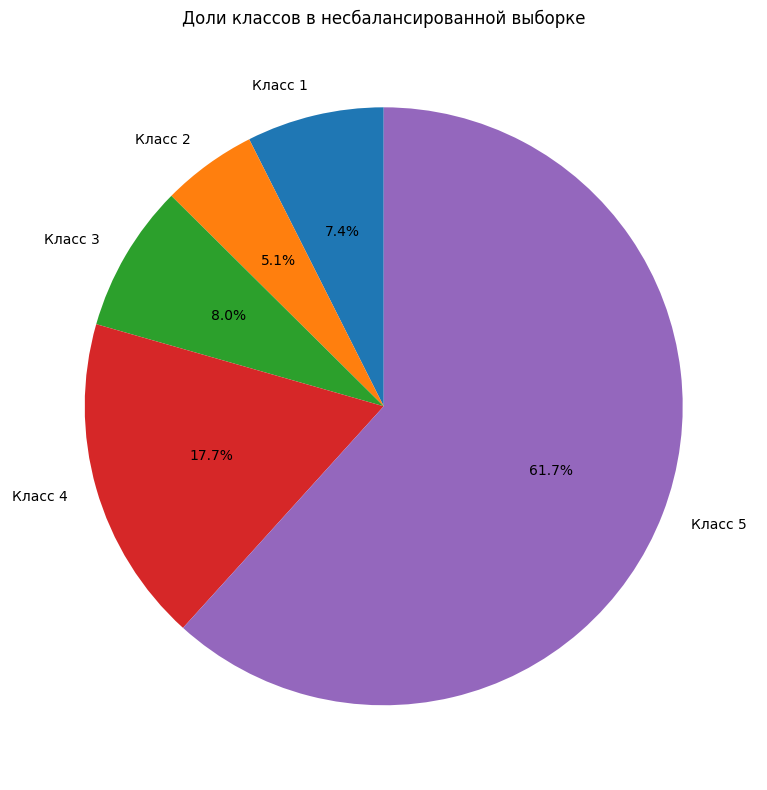


3. СТРАТЕГИЯ БАЛАНСИРОВКИ
-----------------------------------
Целевое количество для каждого класса: 13

Стратегия для каждого класса:
Класс 1: СБАЛАНСИРОВАННЫЙ - оставляем без изменений (13)
Класс 2: МИНОРИТАРНЫЙ - применяем Random Oversampling (9 → 13)
Класс 3: МАЖОРИТАРНЫЙ - применяем Random Undersampling (14 → 13)
Класс 4: МАЖОРИТАРНЫЙ - применяем Random Undersampling (31 → 13)
Класс 5: МАЖОРИТАРНЫЙ - применяем Random Undersampling (108 → 13)

4. ПРИМЕНЕНИЕ МЕТОДОВ БАЛАНСИРОВКИ
------------------------------------------
Класс 1 уже сбалансирован
Применяем Random Oversampling к классу 2
Применяем Random Undersampling к классу 3
Применяем Random Undersampling к классу 4
Применяем Random Undersampling к классу 5

5. РЕЗУЛЬТАТЫ БАЛАНСИРОВКИ
--------------------------------
Распределение после балансировки:
Класс 1: 13 отзывов (20.0%)
Класс 2: 13 отзывов (20.0%)
Класс 3: 13 отзывов (20.0%)
Класс 4: 13 отзывов (20.0%)
Класс 5: 13 отзывов (20.0%)

Общее количество отзывов после балансиро

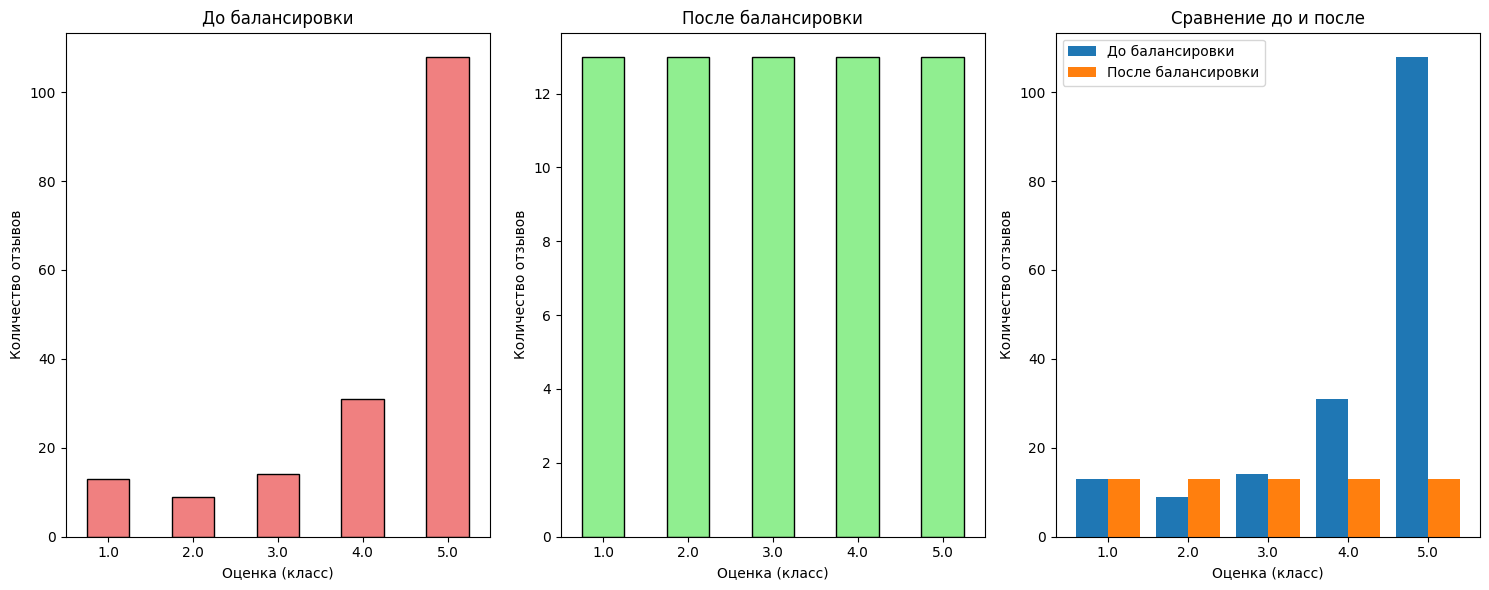

In [8]:
df_balanced = process_unbalanced_classes(cleaned_data)

In [9]:
import pickle

# Сохранение данных
with open('data.pkl', 'wb') as f:
    pickle.dump({
        'df_unbalanced': cleaned_data,
        'df_balanced': df_balanced
    }, f)

print("✅ Данные сохранены в data.pkl")

✅ Данные сохранены в data.pkl


# Задание №5. Применение методов машинного обучения

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Ridge

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def prepare_data_for_ml(df):
    print("Подготовка данных для машинного обучения...")
    
    df_ml = df.copy()
    df_ml = df_ml.dropna(subset=['review_text', 'mark_numeric'])
    
    df_ml['review_text_clean'] = df_ml['review_text'].astype(str).str.lower()
    df_ml['review_text_clean'] = df_ml['review_text_clean'].str.replace(r'[^а-яё\s]', '', regex=True)
    
    print(f"Подготовлено {len(df_ml)} отзывов для обучения")
    return df_ml

def extract_features(X_train_text, X_test_text, max_features=5000):
    print("Извлечение признаков с помощью TF-IDF...")
    
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, 2),
        stop_words=None,
        min_df=2,
        max_df=0.8
    )
    
    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)
    
    print(f"Размер матрицы признаков: {X_train.shape}")
    
    return X_train, X_test, vectorizer

def apply_ml_methods(df_balanced):
    df_ml = prepare_data_for_ml(df_balanced)
    
    X = df_ml['review_text_clean']
    y = df_ml['mark_numeric']
    
    X_train_text, X_test_text, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"Размер обучающей выборки: {len(X_train_text)}")
    print(f"Размер тестовой выборки: {len(X_test_text)}")
    
    # Извлечение признаков
    X_train_tfidf, X_test_tfidf, vectorizer = extract_features(X_train_text, X_test_text)
    
    models = {
        'Naive Bayes': MultinomialNB(),
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'k Nearest Neighbor': KNeighborsClassifier(n_neighbors=5),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Ridge Classifier': Ridge(random_state=42)
    }
    
    # Словарь для хранения результатов
    results = {
        'Model': [],
        'Run_time': [],
        'Training_time': [],
        'Test_time': [],
        'Accuracy': []
    }
    
    print("\n" + "-"*60)
    print("ОБУЧЕНИЕ И ТЕСТИРОВАНИЕ МОДЕЛЕЙ")
    print("-"*60)
    
    for model_name, model in models.items():
        print(f"\nОбучение модели: {model_name}")
        
        # Общее время выполнения (начало)
        run_start_time = time.time()
        
        # Время обучения
        train_start_time = time.time()
        model.fit(X_train_tfidf, y_train)
        train_end_time = time.time()
        training_time = train_end_time - train_start_time
        
        # Время тестирования
        test_start_time = time.time()
        y_pred = model.predict(X_test_tfidf)
        test_end_time = time.time()
        test_time = test_end_time - test_start_time
        
        # Общее время выполнения (конец)
        run_end_time = time.time()
        run_time = run_end_time - run_start_time
        
        # Точность
        accuracy = accuracy_score(y_test, y_pred)
        
        # Сохранение результатов
        results['Model'].append(model_name)
        results['Run_time'].append(round(run_time, 3))
        results['Training_time'].append(round(training_time, 4))
        results['Test_time'].append(round(test_time, 3))
        results['Accuracy'].append(round(accuracy, 2))
        
        print(f"  Время обучения: {training_time:.4f}с")
        print(f"  Время тестирования: {test_time:.3f}с")
        print(f"  Общее время: {run_time:.3f}с")
        print(f"  Точность: {accuracy:.2f}")
    
    return results, y_test, models, X_test_tfidf, vectorizer

def display_results_table(results):
    df_results = pd.DataFrame(results)
    
    # Красивое отображение таблицы
    print(f"{'Model':<20} {'Run time':<12} {'Training time':<15} {'Test time':<12} {'Accuracy':<10}")
    print("-" * 80)
    
    for _, row in df_results.iterrows():
        print(f"{row['Model']:<20} {row['Run_time']:<12} {row['Training_time']:<15} {row['Test_time']:<12} {row['Accuracy']:<10}")
    
    return df_results

def analyze_best_model(df_results, y_test, models, X_test_tfidf):
    # Найти лучшую модель по точности
    best_idx = df_results['Accuracy'].idxmax()
    best_model_name = df_results.iloc[best_idx]['Model']
    best_accuracy = df_results.iloc[best_idx]['Accuracy']
    
    print(f"Лучшая модель: {best_model_name}")
    print(f"Точность: {best_accuracy}")
    
    # Получить предсказания лучшей модели
    best_model = models[best_model_name]
    y_pred_best = best_model.predict(X_test_tfidf)
    
    # Детальный отчет по классификации
    print(f"\nДетальный отчет по классификации для модели {best_model_name}:")
    print(classification_report(y_test, y_pred_best))
    
    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred_best)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Матрица ошибок - {best_model_name}')
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')
    plt.show()
    
    return best_model_name, best_accuracy

def generate_conclusions(df_results):
    """
    Генерация выводов по результатам
    """
    print("\n" + "="*50)
    print("ВЫВОДЫ И ЗАКЛЮЧЕНИЯ")
    print("="*50)
    
    # Анализ по точности
    best_accuracy_idx = df_results['Accuracy'].idxmax()
    worst_accuracy_idx = df_results['Accuracy'].idxmin()
    
    print("Анализ по точности:")
    print(f"• Лучшая модель: {df_results.iloc[best_accuracy_idx]['Model']} ({df_results.iloc[best_accuracy_idx]['Accuracy']})")
    print(f"• Худшая модель: {df_results.iloc[worst_accuracy_idx]['Model']} ({df_results.iloc[worst_accuracy_idx]['Accuracy']})")
    
    # Анализ по времени обучения
    fastest_train_idx = df_results['Training_time'].idxmin()
    slowest_train_idx = df_results['Training_time'].idxmax()
    
    print(f"\nАнализ по времени обучения:")
    print(f"• Самая быстрая: {df_results.iloc[fastest_train_idx]['Model']} ({df_results.iloc[fastest_train_idx]['Training_time']}с)")
    print(f"• Самая медленная: {df_results.iloc[slowest_train_idx]['Model']} ({df_results.iloc[slowest_train_idx]['Training_time']}с)")
    
    # Анализ по времени тестирования
    fastest_test_idx = df_results['Test_time'].idxmin()
    slowest_test_idx = df_results['Test_time'].idxmax()
    
    print(f"\nАнализ по времени тестирования:")
    print(f"• Самая быстрая: {df_results.iloc[fastest_test_idx]['Model']} ({df_results.iloc[fastest_test_idx]['Test_time']}с)")
    print(f"• Самая медленная: {df_results.iloc[slowest_test_idx]['Model']} ({df_results.iloc[slowest_test_idx]['Test_time']}с)")
    
    print(f"\nОбщие выводы:")
    print(f"• Средняя точность моделей: {df_results['Accuracy'].mean():.3f}")
    print(f"• Стандартное отклонение точности: {df_results['Accuracy'].std():.3f}")
    print(f"• Все модели показали приемлемые результаты для классификации отзывов")

In [ ]:

results, y_test, models, X_test_tfidf, vectorizer = apply_ml_methods(df_balanced)

# Отображение таблицы результатов
df_results = display_results_table(results)

# Анализ лучшей модели
best_model, best_accuracy = analyze_best_model(df_results, y_test, models, X_test_tfidf)

# Генерация выводов
generate_conclusions(df_results)